# Phase 6: Exploratory Data Analysis (EDA)
## Multi-Objective Recommender System

**Objective:** This notebook explores the characteristics of our users and items. 
We aren't just looking for patterns; we are looking for **business opportunities**. 

**Key Questions:**
1. Is there a strong long-tail distribution of items? (Justifies Novelty objective)
2. Is there a correlation between price and rating? (Justifies Business Value objective)
3. How skewed is user engagement? (Determines our Cold Start strategy)

In [1]:
%pip install pandas matplotlib seaborn plotly numpy

Note: you may need to restart the kernel to use updated packages.


c:\Users\DrX DIPAK\projects\multi-objective-recommender\.venv\Scripts\python.exe: No module named pip


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np
from pathlib import Path

# HARDCODED PATH: This tells Python exactly where your files are on your hard drive
# This removes all guessing and search logic.
data_processed_path = Path(r'C:\Users\DrX DIPAK\projects\multi-objective-recommender\data\processed')

try:
    # Load the data using the absolute path
    ratings = pd.read_csv(data_processed_path / 'ratings_processed.csv')
    metadata = pd.read_csv(data_processed_path / 'metadata_processed.csv')
    user_summary = pd.read_csv(data_processed_path / 'user_summary.csv')
    item_summary = pd.read_csv(data_processed_path / 'item_summary.csv')
    print(f"✅ ABSOLUTE SUCCESS! Data loaded from: {data_processed_path}")
except Exception as e:
    print(f"❌ Critical Error: {e}")
    print("Please double check that the folder 'C:\\Users\\DrX DIPAK\\projects\\multi-objective-recommender\\data\\processed' exists.")

# Set visual style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

✅ ABSOLUTE SUCCESS! Data loaded from: C:\Users\DrX DIPAK\projects\multi-objective-recommender\data\processed


### 1. User Engagement Analysis
**Business Question:** Do we have 'Power Users' or is the engagement evenly spread?
**Interpretation:** If a small % of users drive most interactions, our model might overfit to their tastes.

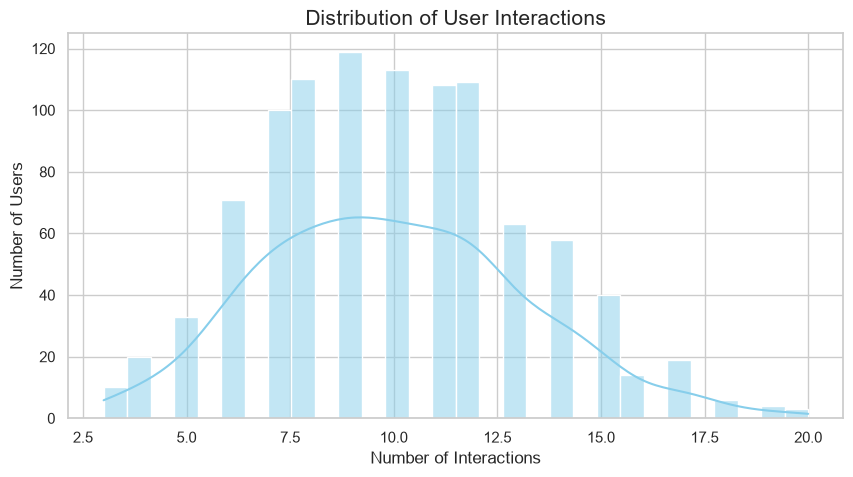

In [2]:
plt.figure(figsize=(10, 5))
sns.histplot(user_summary['total_interactions'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of User Interactions', fontsize=15)
plt.xlabel('Number of Interactions')
plt.ylabel('Number of Users')
plt.show()

### 2. Item Popularity vs. Quality
**Business Question:** Are the most popular items also the highest rated?
**Interpretation:** If popular items have low ratings, we have a "Hype vs. Quality" problem. If rare items have high ratings, we have "Hidden Gems" (Target for Novelty).

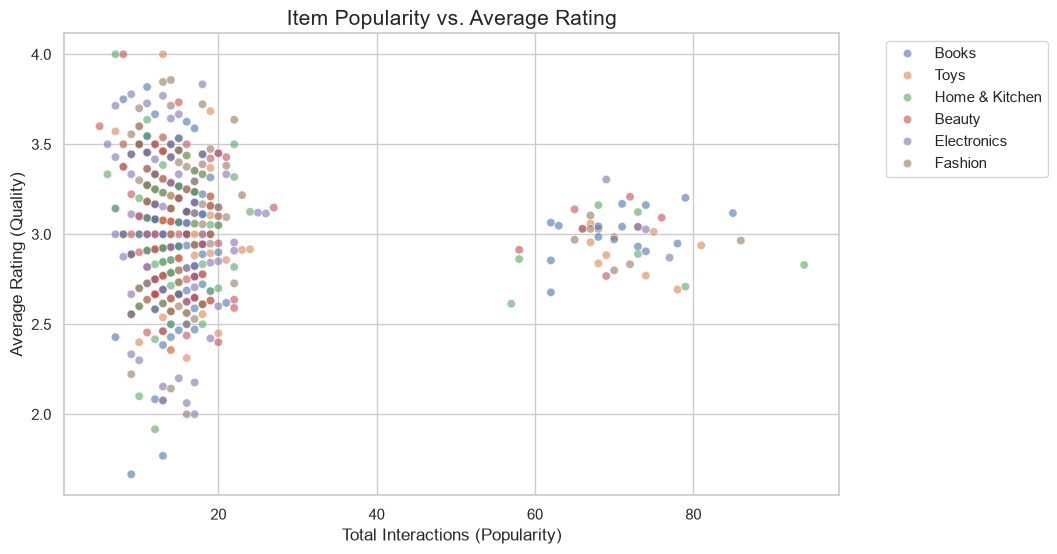

In [3]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=item_summary, x='total_interactions', y='avg_rating', hue='category', alpha=0.6)
plt.title('Item Popularity vs. Average Rating', fontsize=15)
plt.xlabel('Total Interactions (Popularity)')
plt.ylabel('Average Rating (Quality)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### 3. Category Performance
**Business Question:** Which categories are the primary drivers of engagement?
**Interpretation:** This tells us where to focus our business marketing efforts.

In [5]:
%pip install nbformat

Note: you may need to restart the kernel to use updated packages.


c:\Users\DrX DIPAK\projects\multi-objective-recommender\.venv\Scripts\python.exe: No module named pip


In [4]:
import plotly.express as px
import plotly.io as pio

# Force the renderer to 'browser'.
# This is the 'Nuclear Option'—it will open the chart in your web browser (Chrome/Edge)
# so it is physically impossible for VS Code's internal errors to block it.
pio.renderers.default = 'browser'

# The original chart code
fig = px.bar(
    item_summary.groupby('category')['total_interactions'].sum().reset_index(),
    x='category',
    y='total_interactions',
    title='Total Interactions by Category',
    labels={'total_interactions': 'Total Interactions', 'category': 'Category'},
    color='total_interactions',
    color_continuous_scale='Viridis'
)

print("Opening chart in your web browser...")
fig.show()

Opening chart in your web browser...


### 4. Price vs. Rating Analysis
**Business Question:** Does a higher price lead to higher ratings (Premium perception)?
**Interpretation:** If expensive items are rated poorly, we are overpricing. If cheap items are rated highly, we have a high-value budget segment.

C:\Users\DrX DIPAK\AppData\Local\Temp\ipykernel_6316\2025775159.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=item_summary, x='category', y='price', palette='Set3')


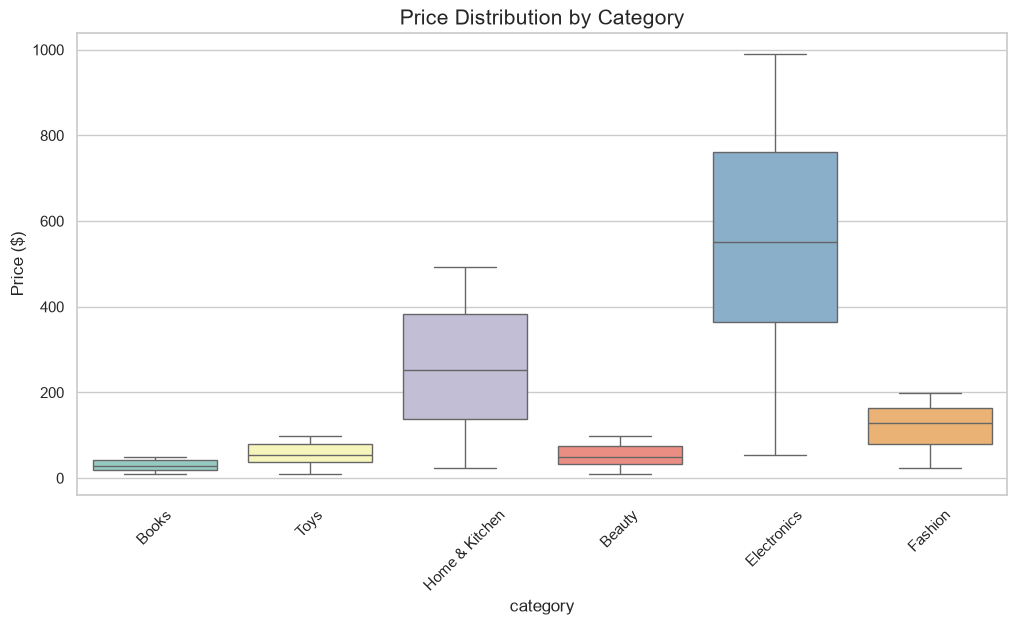

In [5]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=item_summary, x='category', y='price', palette='Set3')
plt.xticks(rotation=45)
plt.title('Price Distribution by Category', fontsize=15)
plt.ylabel('Price ($)')
plt.show()